In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from pathlib import Path

In [3]:
train_path=Path('/kaggle/input/datasets/testkumar02/dataset-stare')

In [4]:
import os
import shutil

In [5]:
from fastai.vision.all import *

In [12]:
from PIL import Image
import numpy as np

def labels_to_png(src,dst):
  dst.mkdir(exist_ok=True)

  for p in src.iterdir():
    mask=Image.open(p)
    mask=np.array(mask)

    mask=(mask>0).astype(np.uint8)
    Image.fromarray(mask).save(dst/f'{p.stem[:-3]}.png')

In [13]:
train_src_input=train_path/'labels'
train_dst_input=Path('/kaggle/working/trainmasks_png')

labels_to_png(train_src_input,train_dst_input)

In [18]:
import random
from tqdm import tqdm

train_img_dir=train_path/'images'
train_mask_dir=Path('/kaggle/working/trainmasks_png')

trainimg_aug_dir=Path('/kaggle/working/trainimg_aug')
trainmask_aug_dir=Path('/kaggle/working/trainmasks_aug')

trainimg_aug_dir.mkdir(exist_ok=True)
trainmask_aug_dir.mkdir(exist_ok=True)

In [19]:
def random_vertical_crop(img,mask,random_pct=0.8):
  w,h=img.size
  new_h=int(h*random.uniform(random_pct,1.0))
  h_start=random.choice([0,h-new_h])
  img_crop=img.crop((0,h_start,w,h_start+new_h))
  mask_crop=mask.crop((0,h_start,w,h_start+new_h))
  img_crop=img_crop.resize((w,h),Image.BILINEAR)
  mask_crop=mask_crop.resize((w,h),Image.NEAREST)
  return img_crop,mask_crop

In [20]:
c=325 # strating image augmentation
n_crop=5

for img_path in tqdm(get_image_files(train_img_dir)):
  img=Image.open(img_path)
  mask=Image.open(train_mask_dir/f"{img_path.stem}.png")
  img.save(trainimg_aug_dir/f"{img_path.stem}.png")
  mask.save(trainmask_aug_dir/f"{img_path.stem}.png")
  for i in range(n_crop):
    img_aug,mask_aug=random_vertical_crop(img,mask,0.8)
    img_aug.save(trainimg_aug_dir/f"im0{c}.png")
    mask_aug.save(trainmask_aug_dir/f"im0{c}.png")
    c+=1

100%|██████████| 20/20 [00:33<00:00,  1.66s/it]


In [21]:
import torch

def pixel_accuracy(inp, targ):
    pred = inp.argmax(dim=1)  # [bs, H, W]
    return (pred == targ).float().mean()

In [22]:
dls=SegmentationDataLoaders.from_label_func('/kaggle/working',fnames=get_image_files(trainimg_aug_dir),
                                            label_func=lambda o: trainmask_aug_dir/f'{o.stem}.png',
                                            codes=["background", "vessels"], item_tfms=Resize(1024), bs=2)

In [23]:
# for custom normalization
n=0
mean=0
std=0

for b in dls.train: # dls contains both train and valid tuples
  batch=b[0] # ignoring labels
  bs=batch.size(0)
  batch=batch.view(bs,3,-1)
  mean+=batch.mean(2).sum(0)
  std+=batch.std(2).sum(0)
  n+=bs

mean/=n
std/=n

In [24]:
print(mean)
print(std)

TensorImage([0.6854, 0.3761, 0.1177], device='cuda:0')
TensorImage([0.2856, 0.1550, 0.0645], device='cuda:0')


In [25]:
import cv2

class CLAHETransform(Transform):
  def encodes(self, x: PILImage):
    x=np.array(x)
    green=x[:,:,1]
    clahe=cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
    enhanced=clahe.apply(green)
    return PILImage.create(enhanced)

class GreenTransform(Transform):
  def encodes(self,x: PILImage):
    x=np.array(x)
    green=x[:,:,1]
    return PILImage.create(green)

In [26]:
def create_matched_filter(size=7, sigma=1.25,theta=0):
  half=size//2
  x,y=np.meshgrid(np.arange(-half,half+1), np.arange(-half,half+1))
  x_theta=x*np.cos(theta)+y*np.sin(theta)
  y_theta=-x*np.sin(theta)+y*np.cos(theta)

  g=np.exp(-(y_theta**2)/2*sigma**2)
  kernel=g-g.mean()

  return kernel

In [27]:
def build_filter_bank():
  filters=[]
  angles=np.linspace(0,np.pi,12)
  for theta in angles:
    filter=create_matched_filter(size=7,sigma=1.25,theta=theta)
    filters.append(filter)

  return filters

In [28]:
def matched_filter_response(img,filters):
  responses=[]

  for filter in filters:
    response=cv2.filter2D(img,-1,filter)
    responses.append(response)

  responses=np.stack(responses,axis=-1)
  max_response=np.max(responses,axis=-1)

  return max_response

In [29]:
class MatchFilter(Transform):
  def __init__(self):
    self.filters=build_filter_bank()

  def encodes(self,x: PILImage):
    x=np.array(x)
    mf=matched_filter_response(x,self.filters)
    mf=cv2.normalize(mf,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
    return PILImage.create(mf)

In [30]:
from skimage.filters import frangi

#multi-scale line detection usig Hessian
class VesselnessTransform(Transform):
  def encodes(self,x: PILImage):
    x=np.array(x)
    vessel=frangi(x)
    vessel=cv2.normalize(vessel,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
    return PILImage.create(vessel)

In [31]:
class ScaleSpaceTransform(Transform):
  def __init__(self, sigmas=[1,2,3]):
    self.sigmas=sigmas

  def encodes(self, img:PILImage):
    mf=np.array(MatchFilter()(img)).astype(np.uint8)
    vt=np.array(VesselnessTransform()(img)).astype(np.uint8)
    x=np.array(img)
    scales=[]
    for s in self.sigmas:
        blurred=cv2.GaussianBlur(x,(0,0),sigmaX=s,sigmaY=s)
        scales.append(blurred)

    sst=np.max(np.stack(scales,axis=-1),axis=-1)
    sst=cv2.normalize(sst,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)

    x_final=np.stack([mf,vt,sst],axis=-1)
    return PILImage.create(x_final)

In [32]:
from tqdm import tqdm

def preprocess(input_path,out_path,resize=False):
  for img_path in tqdm(get_image_files(input_path)):
    img=np.array(PILImage.create(img_path))
    img=CLAHETransform()(img)
    img=ScaleSpaceTransform()(img)
    if resize:
      img=cv2.resize(img,(1024,1024),interpolation=cv2.INTER_CUBIC)
    Image.fromarray(img).save(out_path/f'{img_path.stem}.png')

In [33]:
trainimg_aug_processed_dir=Path('/kaggle/working/trainimg_aug_processed')
trainimg_aug_processed_dir.mkdir(exist_ok=True)

In [34]:
preprocess(trainimg_aug_dir,trainimg_aug_processed_dir)

100%|██████████| 120/120 [00:33<00:00,  3.56it/s]


In [35]:
dls=SegmentationDataLoaders.from_label_func('/kaggle/working',fnames=get_image_files(trainimg_aug_processed_dir),
                                            label_func=lambda o: trainmask_aug_dir/f'{o.stem}.png',
                                            codes=["background", "vessels"],
                                            item_tfms=[Resize(1024)],
                                            batch_tfms=[
                                                 Normalize.from_stats(mean,std)
                                            ],
                                            bs=2)

In [36]:
learn=unet_learner(dls,resnet34, metrics=[pixel_accuracy, Dice()])
learn.fine_tune(8)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 167MB/s] 


epoch,train_loss,valid_loss,pixel_accuracy,dice,time
0,0.246732,0.138809,0.946911,0.636403,01:31


epoch,train_loss,valid_loss,pixel_accuracy,dice,time
0,0.115047,0.104389,0.959286,0.763473,01:33
1,0.100926,0.103315,0.958291,0.714564,01:33
2,0.090665,0.081218,0.966899,0.820160,01:32
3,0.077979,0.069876,0.971336,0.839112,01:32
4,0.069820,0.066774,0.972329,0.839438,01:32
5,0.063108,0.062749,0.973845,0.848787,01:32
6,0.058534,0.060080,0.974688,0.853575,01:32
7,0.056503,0.059594,0.974786,0.855132,01:32


In [37]:
def postprocess(pred,threshold=0.3):
  vessel_prob=pred[1]
  vessel_th=(vessel_prob>threshold).cpu().numpy().astype(np.uint8)

  kernel=np.ones((1,1),np.uint8)

  #Morphological operations
  opened=cv2.morphologyEx(vessel_th,cv2.MORPH_OPEN,kernel)
  closed=cv2.morphologyEx(opened,cv2.MORPH_CLOSE,kernel)

  return closed

In [38]:
def dice_score(pred,target):
  intersection=(pred*target).sum()
  return (2*intersection)/(pred.sum()+target.sum()+1e-8)

In [39]:
preds,targs=learn.get_preds(dl=dls.valid)

In [40]:
dices=[]
for pred,target in zip(preds,targs):
  pred=postprocess(pred,0.3)
  target=np.array(target)
  dices.append(dice_score(pred,target))
print("Mean Dice Score: ",np.mean(dices))

Mean Dice Score:  0.8462958042451723


In [41]:
import matplotlib.pyplot as plt
def show_segmentation(n=6,threshold=0.3):
  for i in range (0,n):
    img=PILImage.create(dls.valid.items[i])
    gt=(targs[i].cpu().numpy()>0).astype(np.uint8)
    gt_vis=gt*255

    pred=postprocess(preds[i],threshold)
    pred_vis=pred*255

    fig,axs=plt.subplots(1,3,figsize=(12,4))
    axs[0].imshow(img)
    axs[0].set_title("Fundus Image")

    axs[1].imshow(gt_vis,cmap="gray",vmin=0,vmax=255)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_vis,cmap="gray",vmin=0,vmax=255)
    axs[2].set_title("Prediction")

    for ax in axs:
      ax.axis("off")
    plt.show()

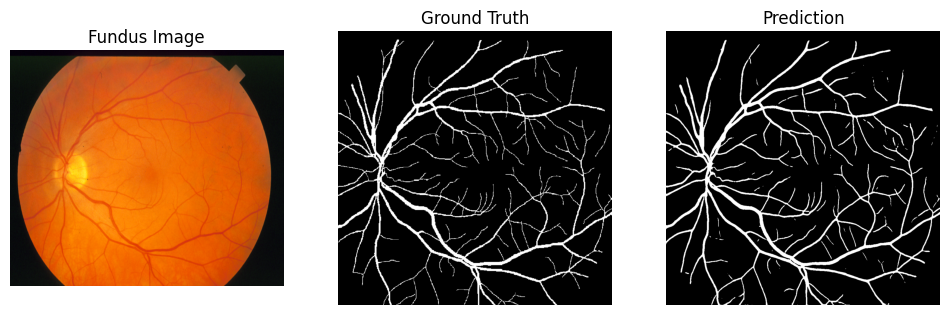

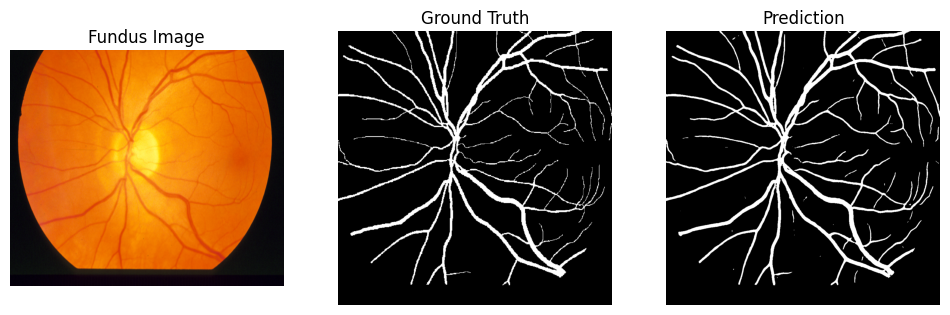

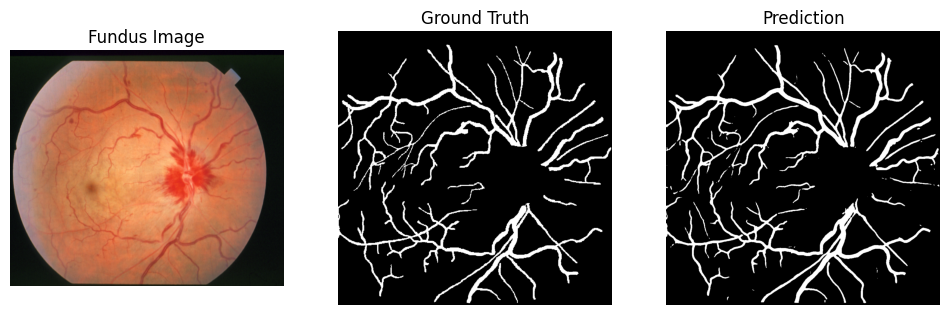

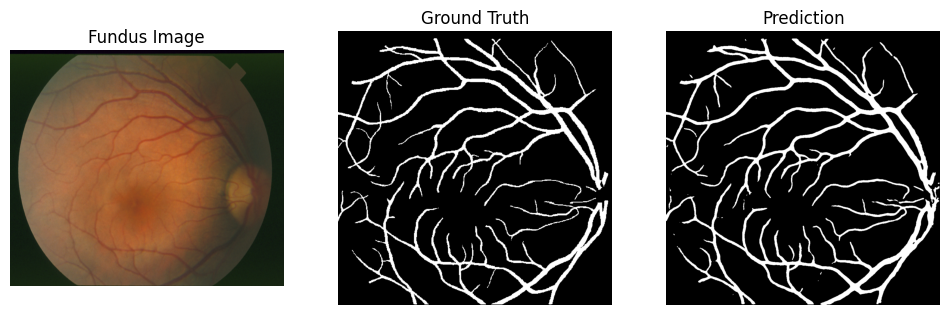

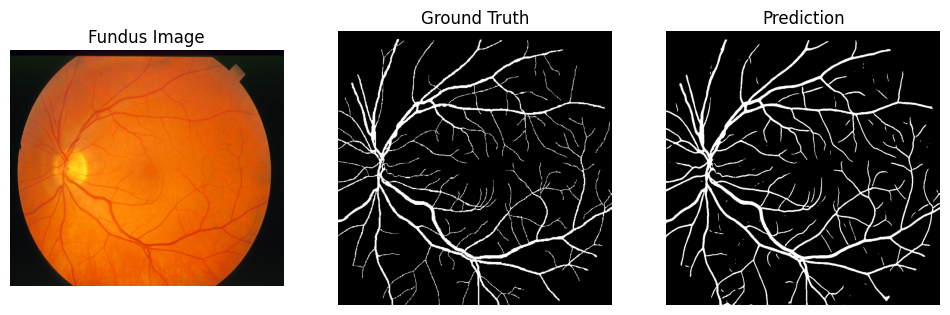

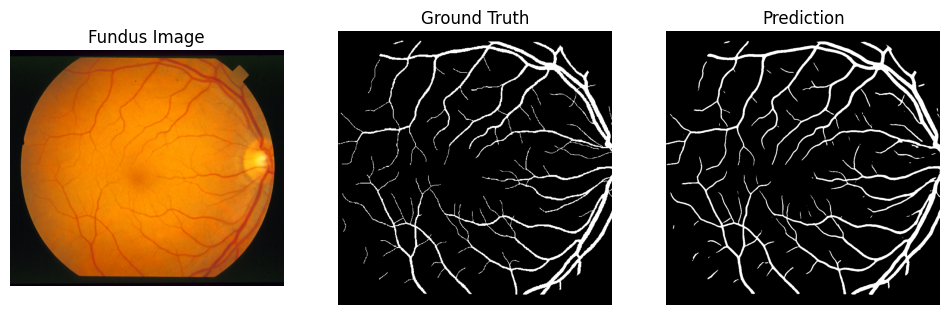

In [42]:
show_segmentation(6,0.3)